# RK4 metodoaren trunkatze-errorearen analisia — LittleEphemeris OPTIMIZATUA

Notebook honetan Runge-Kutta 4 (RK4) metodoaren trunkatze-errorea aztertuko da, **LittleEphemeris-en bertsioa optimizatua** erabiliz (`searchsortedlast`, `@view`, `SVector`).

Helburua da integrazio-pausoa ($h$) aldatuz errorea nola aldatzen den ikustea eta teorikoki espero den $O(h^4)$ portaera betetzen den egiaztatzea.

Horretarako, `m_out` parametroa (irteera bakoitzeko pauso kopurua) aldatuko dugu: 1, 2, 4, 8... Balio honek $h$ txikitzea dakar ($h \propto 1/m$).

### 1. Beharrezko Paketeak eta SPICE Kernelak

Lehenik eta behin, simulaziorako beharrezkoak diren Julia paketeak kargatzen dira (`LittleEphemeris`, `Plots`, `LinearAlgebra`, etab.).

Bestalde, NASAren SPICE sistema erabiltzen da planeten eta ilargiaren efemeride zehatzak kudeatzeko. Horretarako, bi kernel kargatzen dira:
*   `naif0012.tls`: Segundo interkalarren informazioa (denbora kudeatzeko).
*   `de440.bsp`: Planeta nagusien eta ilargiaren posizio datuak (efemerideak).

In [1]:
# LittleEphemeris LOKALA kargatu (optimizazioekin), include bidez
# GravitationSimulation EZ erabili, bestela pakete bertsioa kargatuko luke
include("/home/mikel/Ingenieritza_Informatikoa/GrAL/aitorren_lana/LittleEphemeris.jl-main/src/LittleEphemeris.jl")
using .LittleEphemeris

# RK4 eta f_all! zuzenean kargatu (GravitationSimulation-etik kanpo)
include("../src/integrator.jl")
include("../src/equations.jl")

f_BigFloat! (generic function with 1 method)

In [2]:
# LittleEphemeris dagoeneko kargatuta dago (lokaleko include bidez)
using JSON
using CSV
using SPICE
using DataFrames
using FFTW
using Plots
using BenchmarkTools
using LinearAlgebra
using StaticArrays
using IRKGaussLegendre

In [3]:
# Karga nukleoak
furnsh("./data/naif0012.tls", "./data/de440.bsp")

### 2. Efemerideen Interpolazio Koefizienteen Sorkuntza

Atal honetan, Eguzki Sistemako gorputz nagusi guztien posizioak prestatzen dira. `LittleEphemeris` paketeak SPICE kernelak irakurtzen ditu eta Chebyshev polinomioen bidez hurbiltzen ditu gorputzen ibilbideak. Honek simulazioan zehar planeten posizioak oso azkar kalkulatzea ahalbidetzen du.

Kargatzen diren gorputzak:
*   Planetak: Merkurio, Artizarra, Lurra, Marte, Jupiter, Saturno, Urano, Neptuno.
*   Besteak: Eguzkia eta Ilargia.

Denbora tartea 2029ko urtarrilera mugatzen da.

In [4]:
# Gorputzen koefizienteak kargatu
# 3: Earth-Moon Barycenter, 5: Jupiter Barycenter, 10: Sun, 301: Moon
# 1: Mercury, 2: Venus, 4: Mars, 6: Saturn, 7: Uranus, 8: Neptune
ID_list = [1, 2, 3, 4, 5, 6, 7, 8, 10, 301]

# Denbora tartea zehatza (apophis_pos.txt fitxategiarekin bat egiteko)
# Assisten simulazioaren hasiera (2029ko urtarrilaren 1a) eta bukaera (2030eko urtarrilaren 1a)
et_0 = 10593.535998938605 * 86400
#et_end = 10958.037242609542 * 86400
et_end = et_0 + 50*86400
time_interval = (et_0, et_end)
time_interval_list = fill(time_interval, length(ID_list))

# Koefizienteak sortu (denbora tarte osorako)
println("▶ create_coeffs_file:")
@time create_coeffs_file("./data/coeffs.json", "./data/coeffs.csv", ID_list, time_interval_list)

println("\n▶ BodyCoeffs objektuak sortzen (gorputz bakoitzeko):")
@time Mercury = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 1, time_interval);
@time Venus   = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 2, time_interval);
@time Earth   = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 3, time_interval);
@time Mars    = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 4, time_interval);
@time Jupiter = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 5, time_interval);
@time Saturn  = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 6, time_interval);
@time Uranus  = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 7, time_interval);
@time Neptune = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 8, time_interval);

@time Sun     = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 10, time_interval);@time Moon    = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 301, time_interval);

▶ create_coeffs_file:
  5.942685 seconds (13.70 M allocations: 692.434 MiB, 11.42% gc time, 99.67% compilation time: 16% of which was recompilation)

▶ BodyCoeffs objektuak sortzen (gorputz bakoitzeko):
  0.250310 seconds (384.73 k allocations: 18.716 MiB, 99.32% compilation time)
  0.001348 seconds (3.91 k allocations: 163.648 KiB)
  0.001133 seconds (3.92 k allocations: 163.711 KiB)
  0.001102 seconds (3.72 k allocations: 159.305 KiB)
  0.001063 seconds (3.63 k allocations: 157.086 KiB)
  0.001141 seconds (3.63 k allocations: 156.961 KiB)
  0.001088 seconds (3.63 k allocations: 157.023 KiB)
  0.001080 seconds (3.63 k allocations: 157.023 KiB)
  0.001088 seconds (3.92 k allocations: 163.930 KiB)
  0.001097 seconds (4.89 k allocations: 187.992 KiB)


### 3. Eredu Dinamikoa eta Integratzailea

Hemen definitzen dira simulazioaren bi zutabe nagusiak:

1.  **`f_all(u, p, t)`**: Higidura ekuazioak definitzen dituen funtzioa.
    *   Sarrerak: `u` (Apophisen egoera: posizioa eta abiadura), `p` (parametroak: masak), `t` (denbora).
    *   Prozesua: Une bakoitzean gorputz guztien (planetak, Eguzkia, Ilargia) posizioa kalkulatzen du eta, Newtonen grabitazio legea erabiliz, Apophisen gaineko azelerazio totala lortzen du.
    *   Irteera: Deribatuen bektorea (abiadura eta azelerazioa).

2.  **`RK4(...)`**: Runge-Kutta 4. ordenako zenbakizko integratzailea.
    *   Ekuazio diferentzialak ($du/dt = f(u,t)$) ebazten ditu denboran aurrera eginez pauso diskretuetan ($h$).
    *   Lau ebaluazio egiten ditu pauso bakoitzeko, errorea $O(h^5)$ ordenakoa izateko pauso bakoitzean (eta $O(h^4)$ globala).

### 4. Hasierako Baldintzak eta Parametro Fisikoak

Simulazioa hasteko beharrezkoak diren balioak ezartzen dira:

*   **Hasierako Egoera ($u_0$)**: Apophisen posizioa eta abiadura 2029ko hasieran. Datu hauek heliozentrikoetatik barizentrikoetara egokitzen dira eta unitateak bihurtzen dira (Unitate Astronomikoetatik/Egunetatik $\to$ Kilometroetara/Segundotara).
*   **Grabitazio Parametroak ($\mu$)**: Gorputz bakoitzaren masa bider grabitazio konstantea ($GM$). Balio hauek ezinbestekoak dira indar grabitatorioa kalkulatzeko.
*   **Integrazio Parametroak**: Integrazio totalaren iraupena (`dt_total`) eta laginketa tartea zehazten dira.

In [ ]:
# Hasierako balioak eta konstanteak
u0 = [-5.5946538550488512E-01, 8.5647564757574512E-01, 3.0415066217102493E-01,
      -1.3818324735921638E-02, -6.0088275597939191E-03, -2.5805044631309632E-03]

# Heliozentrikotik barizentrikora
eguzkia_pos_barizentrikoa = [0.001232781221250307, -0.0012750764430978325, -0.0005187131180711941]
u0[1:3] += eguzkia_pos_barizentrikoa

# Unit conversion
AU = 149597870.7
DAY = 86400.0
u0[1:3] *= AU
u0[4:6] *= (AU / DAY)

# Grabitazio parametroak (km^3/s^2)
mu_S = 1.32712440042e11
mu_E = 398600.435
mu_M = 4902.80
mu_Mer = 22032.09
mu_V = 324858.59
mu_Ma = 42828.37
mu_J = 1.26686534e8
mu_Sat = 3.7931187e7
mu_U = 5.793939e6
mu_N = 6.836529e6

# Egitura komuna f_master!-rentzat. Bi konfigurazio:
# - p_all     : Newton hutsa (gr=false), RK4 zuzeneko deietarako
# - p_all_rel : Newton + GR (gr=true), Integratu_IRK / IRKGL16-rentzat
_mus    = [mu_S, mu_E, mu_M, mu_Mer, mu_V, mu_Ma, mu_J, mu_Sat, mu_U, mu_N]
_bodies = [Sun, Earth, Moon, Mercury, Venus, Mars, Jupiter, Saturn, Uranus, Neptune]
_ids    = [10, 3, 301, 1, 2, 4, 5, 6, 7, 8]

p_all = (mus=_mus, bodies=_bodies, ids=_ids,
    physics = (gr=false, j2_sun=false, j2_earth=false, j3_earth=false, j4_earth=false))

p_all_rel = (mus=_mus, bodies=_bodies, ids=_ids,
    physics = (gr=true, j2_sun=false, j2_earth=false, j3_earth=false, j4_earth=false))

t_0 = et_0
t_end = et_end

N_samples = 100
dt_total = t_end - t_0
dt_out = dt_total / (N_samples - 1)

println("Simulazio parametroak:")
println("Hasiera (ET): $t_0")
println("Bukaera (ET): $t_end")
println("Lagin kopurua (Nomatua): $N_samples")
println("Irteera pausoa (dt_out): $dt_out s (~$(round(dt_out/3600, digits=2)) ordu)")

### 4b. LittleEphemeris Dei Indibidualen Eraginkortasuna

`@btime` erabiliz, gorputz-posizio dei bakar baten eta `f_all!` dei bakar baten denbora eta memoria alokazioak neurtzen ditugu.
Hau da optimizazioen eragin zuzena: `BodyCoeffs(t)` deiak `SVector{3}` (stack, 0 alokazio) edo `Vector{Float64}` (heap, alokazio) itzultzen du.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# @btime: BodyCoeffs(t) dei bakarra (gorputz bat)
# ─────────────────────────────────────────────────────────────────
t_bench = et_0 + 86400.0  # 1 egun hasieratik

println("▶ Sun(t) — posizio dei bakarra:")
@btime $Sun($t_bench)

println("\n▶ Moon(t) — posizio dei bakarra:")
@btime $Moon($t_bench)

println("\n▶ Earth(t) — posizio dei bakarra:")
@btime $Earth($t_bench)

# ─────────────────────────────────────────────────────────────────
# @btime: f_master! dei bakarra, GR aktibatuta (10 gorputz)
# ─────────────────────────────────────────────────────────────────
du_bench = zeros(6)
println("\n▶ f_master!(du, u, p, t) — pauso bakarra (10 gorputz, GR=true):")
@btime f_master!($du_bench, $u0, $p_all_rel, $t_bench)

In [ ]:
# Integratzaile berria: IRKGaussLegendre
# Erabakia: f_master! erabili. GR fisika `p.physics`-en bidez kontrolatzen da.
# Pasa beharreko `p`-ak izan behar du physics=(gr=true,...) eredu erlatibista lortzeko.
function Integratu_IRK(u0, t0, T, h, p, m = 1)
    # Output pausoa
    dt_out = h * m
    tspan = (t0, T)
    
    # Define ODE Problem
    prob = ODEProblem(f_master!, u0, tspan, p)
    
    # Solve using IRKGL16 with fixed time step
    sol = solve(prob, IRKGL16(); dt=h, adaptive=false, saveat = dt_out)
    
    return sol
end

### 5. Trunkatze Errorearen Analisia (Self-Consistency Test)

Atal honetan RK4 integratzailearen zehaztasuna aztertuko dugu **Self-Consistency (Auto-Konsistentzia)** test baten bidez.
Metodo honek simulazioaren emaitzak ez ditu kanpoko erreferentzia batekin alderatzen (ASSIST, JPL...), baizik eta **berezko erreferentzia zehatzago batekin**.

Prozedura:
1.  **Erreferentzia Sortu**: Simulazioa pauso oso txiki batekin exekutatzen da ($h_{ref} = dt_{out} / 64$). Trunkatze errorea $O(h^4)$ denez, soluzio hau "zehatza" dela onartuko dugu konparaziorako.
2.  **Probak Exekutatu**: Simulazio bera errepikatzen da hainbat pauso tamainarekin ($h = dt_{out} / 1, 2, 4...$).
3.  **Errorea Kalkulatu**: Proba bakoitzaren emaitza erreferentziarekin konparatzen da. Fisika berdina denez, ikusten den errore bakarra integratzailearen trunkatze errorea da.

Hemen bai, espero dugu malda **4** izatea (Log-Log grafikoan).

In [ ]:
println("Erreferentziazko soluzioa (uu_ref) kalkulatzen...")

# m altu bat erabili (adibidez 64), hau izango da gure "egia"
m_ref = 64 
h_ref = dt_out / m_ref

# IRK16 + GR (Integratu_IRK barruan f_master! deitzen da, p.physics-ekin)
println("▶ IRK16 erreferentzia (m=$m_ref):")
@time tt_ref, uu_ref = Integratu_IRK(u0, t_0, t_end, h_ref, p_all_rel, m_ref)

println("Eginda! Orain testa exekutatu dezakezu.")

In [ ]:
m_test_values = [1, 2, 4, 8, 16,32]
h_test = []
err_test = []

for m in m_test_values
    h = dt_out / m
    print("  IRK16 (m=$m): "); @time tt, uu = Integratu_IRK(u0, t_0, t_end, h, p_all_rel, m)

    err = 0.0
    n = length(tt)
    for i in 1:n
        diff = uu[i][1:3] - uu_ref[i][1:3]
        err_inst = norm(diff) / norm(uu_ref[i][1:3])
        err = max(err, err_inst)
    end
    
    push!(h_test, h)
    push!(err_test, err)
    
    println("m=$m, h=$h, Errore Erlatiboa Max: $err")
end

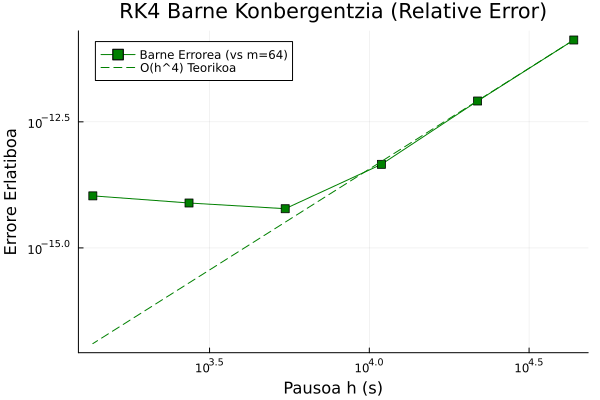

In [10]:
# Grafikoa
plot(h_test, err_test, 
    xaxis=:log, yaxis=:log, 
    marker=:square, 
    label="Barne Errorea (vs m=64)", 
    xlabel="Pausoa h (s)", 
    ylabel="Errore Erlatiboa",
    title="RK4 Barne Konbergentzia (Relative Error)",
    legend=:topleft, color=:green)

# O(h^4) lerroa
# Lerroa pixka bat beherago jartzen dugu hobeto ikusteko
C2 = err_test[1] / (h_test[1]^4)
ref_line2 = [C2 * h^4 for h in h_test]
plot!(h_test, ref_line2, linestyle=:dash, color=:green, label="O(h^4) Teorikoa")

### 6. Efemerideen zarata eta Sinkronizazioa

Aurreko grafikoan ikus daitekeenez, $h$ pausoa txikitzean errorea txikitzen da, teorikoki $O(h^4)$ espero den bezala. Hala ere, balio oso txikietan, portaera irregularra edo "zoru" bat ager daiteke.

Hau gertatzen da efemerideak (planeten posizioak) ez direlako funtzio analitiko perfektuak, baizik eta **zatika definitutako polinomioak** (Chebyshev). 
*   Integrazio pausoak ($h$) polinomio horien "jostura" edo mugak zeharkatzen baditu, errore txikiak sortzen dira interpolazioan.
*   Errore hauek integratzailearen errorearen gainetik jarri daitezke doitasun handian.

Arazo hau minimizatzeko, **denborazko sinkronizazioa** erabiliko dugu hurrengo ataletan: gure integrazio pausoa ($h$) doitu egingo dugu, efemerideen polinomio-luzeraren (`L_MOON`) zatitzaile zehatza izan dadin.

In [10]:
# ==========================================================
# 1. SINKRONIZAZIO OROKORRA (GAKOA)
# ==========================================================
# Ilargiaren polinomio baten iraupena (segundotan)
L_MOON = 345600.0  

# Jatorrizko dt_out nominala (fitxategiaren araberakoa)
# dt_nominala = dt_out 
dt_nominala = dt_out 

# Kalkulatu dt_out "perfektua": L_MOON-en dibisore zehatza dena.
# Honek bermatzen du irteera-puntuak nodoetan erortzea.
n_puntu_polinomioko = round(Int, L_MOON / dt_nominala) 
dt_out_sinkro = L_MOON / n_puntu_polinomioko

println("SINKRONIZAZIO DATUAK:")
println("- dt_out berria: $dt_out_sinkro s")
println("- Polinomio bakoitzeko irteera puntu kopurua: $n_puntu_polinomioko")

SINKRONIZAZIO DATUAK:
- dt_out berria: 43200.0 s
- Polinomio bakoitzeko irteera puntu kopurua: 8


In [ ]:
# ==========================================================
# 2. ERREFERENTZIA INTERNOA (m=128 edo m=64)
# ==========================================================
m_ref = 64
h_ref = dt_out_sinkro / m_ref

println("▶ RK4 erreferentzia sinkronizatua (m=$m_ref):")
@time tt_ref, uu_ref = RK4(u0, t_0, et_end, h_ref, p_all, f_master!, m_ref)
println("Erreferentzia internoa kalkulatuta (m=$m_ref).")

In [ ]:
# ==========================================================
# 3. ANALISI BEGIZTA (Auto-konsistentzia test garbia)
# ==========================================================
m_test_values = [1,2, 4, 8, 16,32]
h_test_emaitzak = Float64[]
err_test_emaitzak = Float64[]

println("\nBarne testa exekutatzen...")

for m in m_test_values
    h = dt_out_sinkro / m
    
    print("  RK4 (m=$m): "); @time tt, uu = RK4(u0, t_0, et_end, h, p_all, f_master!, m)
    
    err = 0.
    n = length(tt)
    for i in 1:n
        err_inst = norm(uu[i][1:3]-uu_ref[i][1:3]) / norm(uu_ref[i][1:3])
        err = max(err, err_inst)
    end
    
    push!(h_test_emaitzak, h)
    push!(err_test_emaitzak, err)
    
    println("m=$m, h=$(round(h, digits=4)) s, Errore Erlatiboa (t=end): $err")
end

# ==========================================================
# 4. MALDA (SLOPE) ETA KONBERGENTZIA
# ==========================================================
if length(h_test_emaitzak) > 1
    log_h = log.(h_test_emaitzak)
    log_E = log.(err_test_emaitzak)
    
    X = hcat(ones(length(log_h)), log_h)
    coeffs = X \ log_E
    
    println("\nANALISI NUMERIKOA:")
    println("- Lortutako malda (p): $(round(coeffs[2], digits=4))")
    println("- Teoria (RK4): 4.0")
end

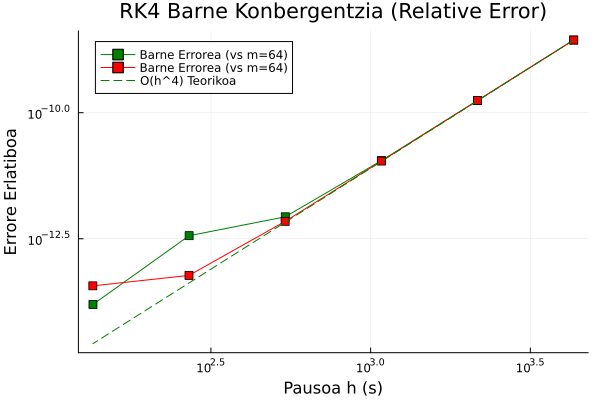

In [22]:
# Grafikoa
plot(h_test, err_test, 
    xaxis=:log, yaxis=:log, 
    marker=:square, 
    label="Barne Errorea (vs m=64)", 
    xlabel="Pausoa h (s)", 
    ylabel="Errore Erlatiboa",
    title="RK4 Barne Konbergentzia (Relative Error)",
    legend=:topleft, color=:green)
plot!(h_test_emaitzak, err_test_emaitzak, 
    xaxis=:log, yaxis=:log, 
    marker=:square, 
    label="Barne Errorea (vs m=64)", 
    xlabel="Pausoa h (s)", 
    ylabel="Errore Erlatiboa",
    title="RK4 Barne Konbergentzia (Relative Error)",
    legend=:topleft, color=:red)

# O(h^4) lerroa
# Lerroa pixka bat beherago jartzen dugu hobeto ikusteko
C2 = err_test[1] / (h_test[1]^4)
ref_line2 = [C2 * h^4 for h in h_test]
plot!(h_test, ref_line2, linestyle=:dash, color=:green, label="O(h^4) Teorikoa")

### 7. Polinomio-Nodoen Bateratzea (Sinkronizazio Osoa)

Aurreko pausoan `h` egokitu dugu polinomioaren luzerarekin ($L_{MOON}$), baina simulazioaren **hasiera puntua ($t_0$)** ausazkoa zen polinomioaren barruan. Honek esan nahi du oraindik mugak zeharkatu ditzakegula pausoaren erdian.

Sinkronizazio osoa lortzeko:
1.  Ilargiaren hurrengo polinomio-muga edo "nodoa" bilatu (`t_ilargiaren_nodo`).
2.  Apophisen egoera puntu horretaraino aurreratu.
3.  Simulazio nagusia **nodo horretatik bertatik** hasi.

Horrela, $h$ pausoa $L_{MOON}$-en zatitzailea denez, eta nodo batean hasten garenez, simulazioaren pauso guztiak polinomio berdinaren barruan edo muga zehatzetan eroriko dira, efemerideetako "zarata" ia guztiz ezabatuz.

In [ ]:
#Ilargiaren gertueneko nodoa
t_ilargiaren_nodo = 0
for time in Moon.timeIntervals
    if time>t_0
        t_ilargiaren_nodo = time
        break
    end
end

#Apophisen datuak ilargiaren nodoan
m = 16
h = 100/m
println("▶ RK4 nodo-ra (m=$m):")
@time u_nodo = RK4(u0, t_0, t_ilargiaren_nodo, h, p_all, f_master!, m)[2][end]

Behin Apophisen datuak une jakin horretan izanda, notoetatik pasata simulatu dezakegu ibilbidea.

In [ ]:
# ==========================================================
# 2. ERREFERENTZIA INTERNOA (m=128 edo m=64)
# ==========================================================
m_ref = 64
h_ref = dt_out_sinkro / m_ref

println("▶ RK4 erreferentzia nodo-tik (m=$m_ref):")
@time tt_ref, uu_ref = RK4(u_nodo, t_ilargiaren_nodo, et_end, h_ref, p_all, f_master!, m_ref)
println("Erreferentzia internoa kalkulatuta (m=$m_ref).")

In [ ]:
# ==========================================================
# 3. ANALISI BEGIZTA (Auto-konsistentzia test garbia)
# ==========================================================
m_test_values = [1,2,4,8,16,32]
h_test_emaitzak_sink = Float64[]
err_test_emaitzak_sink = Float64[]

println("\nBarne testa exekutatzen...")

for m in m_test_values
    h = dt_out_sinkro / m
    
    print("  RK4 (m=$m): "); @time tt, uu = RK4(u_nodo, t_ilargiaren_nodo, et_end, h, p_all, f_master!, m)
    
    err = 0.
    n = length(tt)
    for i in 1:n
        err_inst = norm(uu[i][1:3]-uu_ref[i][1:3]) / norm(uu_ref[i][1:3])
        err = max(err, err_inst)
    end
    
    push!(h_test_emaitzak_sink, h)
    push!(err_test_emaitzak_sink, err)
    
    println("m=$m, h=$(round(h, digits=4)) s, Errore Erlatiboa (t=end): $err")
end

# ==========================================================
# 4. MALDA (SLOPE) ETA KONBERGENTZIA
# ==========================================================
if length(h_test_emaitzak) > 1
    log_h = log.(h_test_emaitzak_sink)
    log_E = log.(err_test_emaitzak_sink)
    
    X = hcat(ones(length(log_h)), log_h)
    coeffs = X \ log_E
    
    println("\nANALISI NUMERIKOA:")
    println("- Lortutako malda (p): $(round(coeffs[2], digits=4))")
    println("- Teoria (RK4): 4.0")
end

### 8. Emaitzen Konparaketa eta Ondorioak

Beheko grafikoan hiru estrategien konparaketa ikusten da:

1.  🔴 **Jatorrizkoa (Gorria)**: Inolako sinkronizaziorik gabe. *Plateau* edo zoru bat ager daiteke doitasun handian, efemerideen interpolazio zarata dela eta.
2.  🟢 **Erdi-sinkronizatua (Berdea)**: Pausoa ($h$) sinkronizatua, baina hasiera puntua ($t_0$) ez. Hobekuntza egon daiteke, baina zarata hondarrak egon daitezke.
3.  🔵 **Sinkronizazio Osoa (Urdina)**: Nodoetatik hasita eta pauso sinkronizatuekin. Hemen RK4 metodoaren $O(h^4)$ portaera garbia ikusi beharko litzateke doitasun maila altuenetaraino.

Honek frogatzen du doitasun handiko simulazioetan garrantzitsua dela integratzailearen pausoak kanpo-datuen (efemerideen) egiturarekin bat egitea.

┌ Warning: Skipped marker arg triangle.
└ @ Plots ~/.julia/packages/Plots/bpxfB/src/args.jl:1155


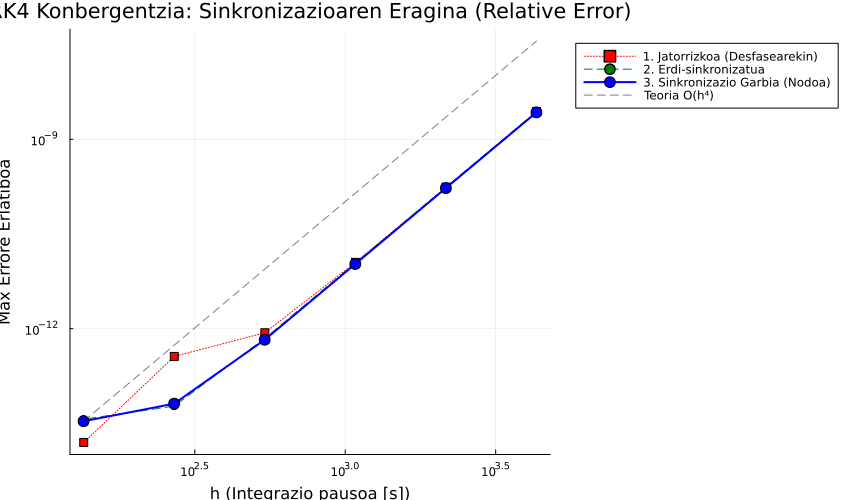

In [27]:
using Plots

# Grafikoaren hasieratzea
p_comp = plot(xaxis=:log, yaxis=:log, 
              xlabel="h (Integrazio pausoa [s])", 
              ylabel="Max Errore Erlatiboa",
              title="RK4 Konbergentzia: Sinkronizazioaren Eragina (Relative Error)",
              legend=:outertopright, 
              grid=true, 
              size=(850, 500))

# 1. Jatorrizko datuak (Sinkronizatu gabe, agian 'plateau' batekin)
plot!(p_comp, h_test, err_test, 
      marker=:square, color=:red, linestyle=:dot,
      label="1. Jatorrizkoa (Desfasearekin)")

# 2. Bigarren saiakera (err_test_emaitzak)
plot!(p_comp, h_test_emaitzak, err_test_emaitzak, 
      marker=:triangle, color=:green, linestyle=:dash,
      label="2. Erdi-sinkronizatua")

# 3. Azken bertsioa (Nodoarekin sinkronizatuta - GAKOA)
plot!(p_comp, h_test_emaitzak_sink, err_test_emaitzak_sink, 
      marker=:circle, markersize=6, color=:blue, linewidth=2,
      label="3. Sinkronizazio Garbia (Nodoa)")

# 4. Erreferentzia Teorikoa (p=4 malda) alderatzeko
h_min, h_max = minimum(h_test_emaitzak_sink), maximum(h_test_emaitzak_sink)
# Lerro teorikoa azken datuen gainean jartzeko konstantea
C_teorikoa = err_test_emaitzak_sink[end] / (h_test_emaitzak_sink[end]^4)
plot!(p_comp, [h_min, h_max], [C_teorikoa * h_min^4, C_teorikoa * h_max^4], 
      line=:dash, color=:black, alpha=0.5,
      label="Teoria O(h⁴)")

display(p_comp)